<a href="https://colab.research.google.com/github/supsi-dacd-isaac/teaching/blob/main/2021SmartGrids/L09_Simulatore_profili_di_carico_EV_controllati.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Simulazione del Controllo della Batteria con Profili EV

Questo notebook esegue la simulazione di un controllo basato su regole per una batteria, utilizzando profili di consumo non controllati e profili di utilizzo dei veicoli elettrici (EV).

Le sezioni principali sono:
- Importazione dei moduli e impostazione del seme per i numeri casuali
- Definizione delle funzioni di controllo della batteria
- Caricamento e preprocessamento dei profili di consumo
- Definizione del modello di spazio di stato per la batteria
- Caricamento ed elaborazione dei profili EV
- Applicazione del controllo per ogni istante temporale
- Salvataggio dei risultati in vari formati

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from tqdm.notebook import tqdm
import os
from os.path import join
from datetime import datetime
import gdown
import zipfile
import pytz

# Imposta il seme per la generazione di numeri casuali
np.random.seed(0)

file_id = '1B_DK-dEhRK1JwNdIFgoxCh6tD16B1XPZ'
url = f'https://drive.google.com/uc?id={file_id}'
output = 'downloaded_file'  # You can customize this based on file type later

# Step 4: Download the file
gdown.download(url, output, quiet=False)

with zipfile.ZipFile(output, 'r') as zip_ref:
    zip_ref.extractall()
print("📁 Contents:", os.listdir('profili utilizzo auto'))

Downloading...
From: https://drive.google.com/uc?id=1B_DK-dEhRK1JwNdIFgoxCh6tD16B1XPZ
To: /content/downloaded_file
100%|██████████| 769k/769k [00:00<00:00, 8.72MB/s]

📁 Contents: ['035_001.csv', '032_001.csv', '040_001.csv', '028_001.csv', '011_001.csv', '035_002.csv', '019_002.csv', '002_002.csv', '004_001.csv', '006_002.csv', '036_001.csv', '051_002.csv', '046_001.csv', '041_001.csv', '037_001.csv', '034_001.csv', '020_001.csv', '048_001.csv', '029_001.csv', '042_001.csv', '038_001.csv', '046_002.csv', '026_001.csv', '025_001.csv', '001_001.csv', '049_001.csv', '039_001.csv', '052_001.csv', '003_002.csv', '008_001.csv', '005_002.csv', '051_001.csv', '042_002.csv', '043_001.csv', '031_001.csv', '033_001.csv', '043_002.csv', '048_002.csv', '040_002.csv', '021_001.csv', '014_001.csv', '014_002.csv', '007_001.csv', '017_001.csv', '037_002.csv', '050_001.csv', '007_002.csv', '024_001.csv', '022_001.csv', '045_002.csv', '027_001.csv', '047_001.csv', '023_001.csv', '009_001.csv', '005_001.csv', '029_002.csv', '006_001.csv', '018_001.csv', '012_001.csv', '045_001.csv', '010_001.csv', '028_002.csv']


## Funzioni di Controllo della Batteria

Nelle celle seguenti definiamo due funzioni:

1. **get_desired_battery_control**: Calcola la potenza desiderata per caricare o scaricare la batteria in base allo stato attuale e alle regole impostate.
2. **apply_control**: Applica il controllo aggiornando lo stato della batteria in base alla potenza fornita.

In [2]:
def get_desired_battery_control(connected, x, dt, eta_ch, eta_ds, Ad, Bd,
                                x_max=15, x_min=0, p_max=5, is_charging=True, soc_start_charge=0.7):
    """
    Controllore basato su regole per la batteria.

    Argomenti:
      connected      : flag che indica se il veicolo è connesso alla stazione di ricarica.
      x              : stato attuale della batteria in kWh.
      dt             : intervallo di campionamento in secondi.
      eta_ch, eta_ds : efficienza di carica e scarica della batteria.
      Ad, Bd         : matrici del modello di stato della batteria.
      x_max, x_min   : limiti massimo e minimo consentiti per lo stato della batteria (in kWh).
      p_max          : potenza massima di carica/scarica (con 0 come potenza minima di carica).
      is_charging    : stato corrente della batteria (True se in carica).
      soc_start_charge: valore soglia di SOC per avviare la carica.

    Ritorna:
      p_batt_actual  : potenza effettivamente applicata alla batteria.
      x_new_corr     : nuovo stato della batteria corretto in base ai limiti.
      is_charging    : flag aggiornato che indica se la batteria sta caricando.
    """
    # Calcola l'energia che fluirà dentro o fuori dalla batteria
    if connected and (x < x_max * soc_start_charge or is_charging):
        p = p_max
        e_batt = p * Bd[0, 0] / 3600  # Conversione da potenza a energia (kWh)
        is_charging = True
    else:
        e_batt = 0

    # Calcola lo stato ipotetico della batteria dopo l'azione
    x_new = Ad[0] * x + e_batt

    # Se il nuovo stato supera il limite massimo, interrompi la carica
    if x_new >= x_max:
        is_charging = False

    # Corregge il nuovo stato rispettando i limiti reali della batteria
    x_new_corr = np.maximum(np.minimum(x_new, x_max), x_min)

    # Calcola la variazione effettiva dello stato e la potenza reale applicata
    x_change = (x_new_corr - Ad[0] * x)[0]
    p_batt_actual = np.clip(dt * (x_change / eta_ch if x_change > 0 else x_change * eta_ds), -p_max, p_max)

    return p_batt_actual, x_new_corr, is_charging


def apply_control(p, x, Ad, Bd, x_max=15, is_charging=True):
    """
    Applica il controllo aggiornando lo stato della batteria.

    Argomenti:
      p           : potenza applicata alla batteria.
      x           : stato attuale della batteria in kWh.
      Ad, Bd      : matrici del modello di stato.
      x_max       : limite massimo dello stato della batteria.
      is_charging : flag che indica se la batteria è in carica.

    Ritorna:
      x_new       : nuovo stato della batteria.
      is_charging : flag aggiornato in base al nuovo stato.
    """
    # Calcola l'energia immessa o prelevata dalla batteria
    e_batt = p * Bd[0, 0] / 3600

    # Calcola il nuovo stato della batteria
    x_new = Ad[0] * x + e_batt

    # Se la batteria ha raggiunto o superato il limite massimo, interrompi la carica
    if x_new >= x_max:
        is_charging = False

    return x_new, is_charging

## Caricamento dei Profili di Consumo Non Controllati

In questa sezione si carica il file CSV contenente i dati di consumo a intervalli di 15 minuti, si effettua l'interpolazione a 1 minuto e si adatta la scala del profilo totale.

In [3]:
!gdown 1F8rP6NoZiTUsu9nNEMN3suIhStaSCn78
df_uncontrolled = pd.read_csv('dati_consumo_15min.csv', header=0, parse_dates=[0], date_format='%d/%m/%Y %H:%M', index_col=0).tz_localize('Etc/GMT-1')
df_uncontrolled.head()

# Somma i profili, campiona a 1 minuto con interpolazione lineare e adatta la scala da energia in kWh a potenza in kW
df_uncontrolled_tot = df_uncontrolled.sum(axis=1).resample('1min').ffill() * 4
df_uncontrolled_tot = df_uncontrolled_tot.rename('p_main_no_ev')
df_uncontrolled_tot = df_uncontrolled_tot[:-1]

df_uncontrolled_tot.head()

Downloading...
From: https://drive.google.com/uc?id=1F8rP6NoZiTUsu9nNEMN3suIhStaSCn78
To: /content/dati_consumo_15min.csv
100% 13.1M/13.1M [00:00<00:00, 38.7MB/s]


,p_main_no_ev
time,
2019-01-01 00:15:00+01:00,1.632892
2019-01-01 00:16:00+01:00,1.632892
2019-01-01 00:17:00+01:00,1.632892
2019-01-01 00:18:00+01:00,1.632892
2019-01-01 00:19:00+01:00,1.632892


## Definizione del Modello di Spazio di Stato per la Batteria

Qui definiamo le matrici del modello in tempo continuo e ne eseguiamo la discretizzazione esatta.

In [4]:
dt = 60               # Tempo di campionamento [s]
eta_ch = 0.95         # Efficienza di carica
eta_ds = 0.95         # Efficienza di scarica
k = -np.log(0.97) / (86400 * 30)  # Auto-scarica: il 3% in un mese

# Calcola le matrici del sistema in tempo continuo
Ac = np.atleast_2d(-k)
Bc = np.atleast_2d(np.array([eta_ch, -1 / eta_ds]))

# Discretizzazione esatta del modello
Ad = np.exp(dt * Ac)
Bd = np.linalg.inv(Ac) @ (Ad - 1) @ Bc
print('Ad: {}\nBd: {}'.format(np.round(Ad, 5), np.round(Bd, 5)))

Ad: [[1.]]
Bd: [[ 56.99998 -63.15787]]


## Caricamento ed Elaborazione dei Profili EV

Questa sezione esegue le seguenti operazioni:
- Ottiene la lista dei file contenenti i profili di utilizzo degli EV.
- Assegna capacità casuali della batteria e consumo (kWh/km) per ogni EV.
- Elabora ciascun file per creare un DataFrame con informazioni sullo stato di carica, variazione del SOC e presenza alla stazione di ricarica (colonna `connected`).
- Unisce i DataFrame di tutti gli EV in un unico DataFrame multiindice.

In [5]:
# Ottieni la lista di tutti i file nella cartella (ordinati per nome)
profile_files = sorted(os.listdir('profili utilizzo auto'))

# Selezione casuale di 30 files (opzionale)
# profile_files = sorted(np.random.choice(profile_files, 30))

dfs = {}
ev_names = [f.split('.')[0] for f in profile_files]
df_profiles = pd.DataFrame(columns=ev_names)

# Assegna capacità della batteria e consumo (kWh/km) casuali per ogni EV
battery_capacity_dict = {ev_name: np.random.uniform(40, 80) for ev_name in ev_names}
kWh_per_km_dict = {ev_name: np.random.uniform(0.15, 0.3) for ev_name in ev_names}

for f in tqdm(profile_files, desc='Processing files'):
    ev_name = f.split('.')[0]
    df_trips = pd.read_csv('profili utilizzo auto/' + f, index_col=0, parse_dates=["arrival_time", "departure_time"])

    # definisci dimensione della batteria, efficienza, e perdita di SOC nei viaggi
    battery_capacity = battery_capacity_dict[ev_name]
    kWh_per_km = kWh_per_km_dict[ev_name]
    soc_lost = 0

    # Crea un DataFrame per l'anno 2019 con frequenza di 1 minuto
    df = pd.DataFrame(0.0, index=pd.date_range('2019-01-01', '2019-12-31 23:59:00',
                                               freq='1min', tz='Etc/GMT-1'),
                      columns=['connected', 'delta_soc', 'soc', 'p_bat'])

    # Aggiorna il DataFrame in base ai viaggi registrati
    for _, trip in df_trips.iterrows():
        soc_lost += kWh_per_km * trip['km']
        if trip['location'] == 'Home':
            connection_start = trip['arrival_time']
            connection_end = trip['departure_time'] - pd.Timedelta('1min')
            df.loc[connection_start:connection_end, 'connected'] = 1
            df.loc[connection_start, 'delta_soc'] = soc_lost % battery_capacity
            soc_lost = 0

    dfs[ev_name] = df

# Unisce i DataFrame dei profili EV in un unico DataFrame multiindice
dfs = pd.concat(dfs, axis=1)
df_trips.head()

Processing files:   0%|          | 0/62 [00:00<?, ?it/s]

,arrival_time,departure_time,km,location
765,2019-01-02 15:04:00+01:00,2019-01-02 19:19:00+01:00,54.636,Event Location
766,2019-01-02 19:40:00+01:00,2019-01-03 17:28:00+01:00,47.437,Home
767,2019-01-03 17:43:00+01:00,2019-01-03 19:47:00+01:00,5.074,Shopping
768,2019-01-03 20:02:00+01:00,2019-01-07 03:45:00+01:00,3.382,Home
769,2019-01-07 04:06:00+01:00,2019-01-07 12:48:00+01:00,25.499,Workplace


In [6]:
dfs.head()

001_001                        002_002            \
                          connected delta_soc  soc p_bat connected delta_soc   
2019-01-01 00:00:00+01:00       0.0       0.0  0.0   0.0       0.0       0.0   
2019-01-01 00:01:00+01:00       0.0       0.0  0.0   0.0       0.0       0.0   
2019-01-01 00:02:00+01:00       0.0       0.0  0.0   0.0       0.0       0.0   
2019-01-01 00:03:00+01:00       0.0       0.0  0.0   0.0       0.0       0.0   
2019-01-01 00:04:00+01:00       0.0       0.0  0.0   0.0       0.0       0.0   

                                       003_002            ... 051_001        \
                           soc p_bat connected delta_soc  ...     soc p_bat   
2019-01-01 00:00:00+01:00  0.0   0.0       0.0       0.0  ...     0.0   0.0   
2019-01-01 00:01:00+01:00  0.0   0.0       0.0       0.0  ...     0.0   0.0   
2019-01-01 00:02:00+01:00  0.0   0.0       0.0       0.0  ...     0.0   0.0   
2019-01-01 00:03:00+01:00  0.0   0.0       0.0       0.0  ...     0.0   0.0   
2019-01-01 00:04:00+01:00  0.0   0.0       0.0       0.0  ...     0.0   0.0   

                            051_002                        052_001            \
                          connected delta_soc  soc p_bat connected delta_soc   
2019-01-01 00:00:00+01:00       0.0       0.0  0.0   0.0       0.0       0.0   
2019-01-01 00:01:00+01:00       0.0       0.0  0.0   0.0       0.0       0.0   
2019-01-01 00:02:00+01:00       0.0       0.0  0.0   0.0       0.0       0.0   
2019-01-01 00:03:00+01:00       0.0       0.0  0.0   0.0       0.0       0.0   
2019-01-01 00:04:00+01:00       0.0       0.0  0.0   0.0       0.0       0.0   

                                      
                           soc p_bat  
2019-01-01 00:00:00+01:00  0.0   0.0  
2019-01-01 00:01:00+01:00  0.0   0.0  
2019-01-01 00:02:00+01:00  0.0   0.0  
2019-01-01 00:03:00+01:00  0.0   0.0  
2019-01-01 00:04:00+01:00  0.0   0.0  

[5 rows x 248 columns]

## Applicazione del Controllo

In questa sezione viene applicato il controllo ad ogni istante temporale:
- Si calcola la potenza desiderata per ciascun EV tramite la funzione `get_desired_battery_control`.
- Si scala la potenza totale per non superare un limite massimo.
- Si aggiorna lo stato di carica per ogni EV usando la funzione `apply_control`.

In [7]:
a_max = 16 # Corrente massima di carica per un singolo veicolo
p_tot_max = 1000  # Potenza totale massima ammessa

p_bat_desired_dict = {ev: 0 for ev in ev_names}
print('Processing control')

# Inizializza lo stato di carica (charging) per ogni EV
is_charging_dict = {ev: False for ev in ev_names}
max_battery_capacities = {ev: battery_capacity_dict[ev] * 0.8 for ev in ev_names}  # 80% della capacità nominale
p_max = a_max * 400 * np.sqrt(3) / 1000  # Calcola la potenza massima di carica/scarica

# Inizializza lo stato di carica temporaneo per ciascun EV (valore casuale tra il 30% e il 100% della capacità massima)
temp_soc_dict = {ev: max_battery_capacities[ev] * np.random.uniform(0.3, 1) for ev in ev_names}

# Commenta questo pezzo di codice per simulare un anno intero!
dfs = dfs.iloc[:1440*7]

# Inizializza a 0 il numero di eventi in cui lasciamo scaricare la macchina sotto a 0
unsatisfied_charges = 0
for index, row in tqdm(dfs.iterrows(), total=dfs.shape[0]):
    for ev in ev_names:
        connected = row[ev]['connected']

        # Aggiorna lo stato di carica temporaneo sottraendo la variazione del SOC
        temp_soc_dict[ev] -= dfs.loc[index, (ev, 'delta_soc')]

        # Verifica che il SOC non diventi negativo
        if dfs.loc[index, (ev, 'soc')] < 0:
            print(f"YOUR SOC IS NEGATIVE! {ev} {index}. I will set it to 0")
            temp_soc_dict[ev] = 0
            unsatisfied_charges += 1

        # Calcola la potenza desiderata
        p_bat_desired_dict[ev], _, is_charging_dict[ev] = get_desired_battery_control(
            connected, temp_soc_dict[ev], dt, eta_ch, eta_ds, Ad, Bd,
            x_max=max_battery_capacities[ev],
            p_max=p_max,
            is_charging=is_charging_dict[ev]
        )

    # Calcola la potenza totale desiderata dalla somma dei singoli EV
    p_desired_total = np.sum(list(p_bat_desired_dict.values()))

    # Calcola il fattore di scala per non superare la potenza totale massima
    if p_desired_total == 0:
        scale_factor = 1
    else:
        scale_factor = max(0, min((p_tot_max - df_uncontrolled_tot.loc[index]) / p_desired_total, 1))

    # Applica il fattore di scala e aggiorna lo stato e la potenza della batteria per ogni EV
    for ev in ev_names:
        p_bat_desired_dict[ev] *= scale_factor
        soc, is_charging_dict[ev] = apply_control(
            p_bat_desired_dict[ev], temp_soc_dict[ev], Ad, Bd,
            x_max=max_battery_capacities[ev],
            is_charging=is_charging_dict[ev]
        )
        dfs.loc[index, (ev, 'p_bat')] = p_bat_desired_dict[ev]
        temp_soc_dict[ev] = soc
        dfs.loc[index, (ev, 'soc')] = soc

Processing control


  0%|          | 0/10080 [00:00<?, ?it/s]

## Visualizzazione e Salvataggio dei Risultati

Infine, salviamo i profili controllati in diversi formati (Pickle e CSV) e a risoluzioni diverse (1 minuto e 15 minuti).

Text(0, 0.5, 'Potenza totale [kW]')

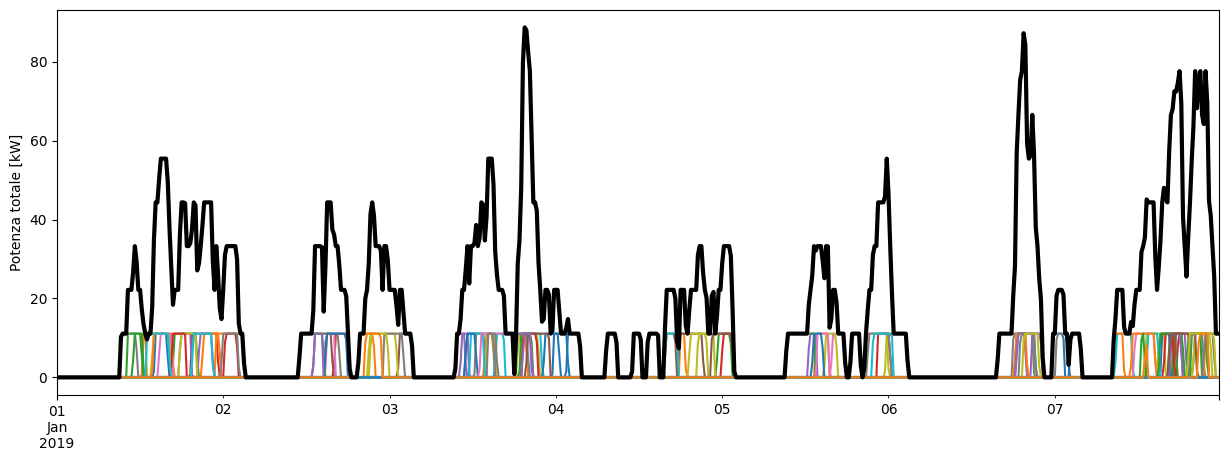

In [8]:
# Salva i profili campionati ogni 15 minuti (media e conversione da potenza ad energia)
dfs_15min = (dfs.resample('15min').mean() / 4)

# Salva separatamente la potenza applicata alla batteria per ogni EV
dfs_15min_pbat = dfs_15min.loc[:, (slice(None), 'p_bat')].droplevel(1, axis=1)


# Plotta una settimana di profili di carica
(dfs_15min_pbat*4).loc['2019-01-01':'2019-01-07'].plot(figsize=(15, 5), legend=None)
plt.ylabel('Potenza [kW]')

# Plotta il profilo totale di carica per la stessa settimana
(dfs_15min_pbat*4).sum(axis=1).loc['2019-01-01':'2019-01-07'].plot(figsize=(15, 5), color='k', linewidth=3)
plt.ylabel('Potenza totale [kW]')

In [9]:
import shutil
from google.colab import files

# Crea la cartella output
os.makedirs('output/{}A'.format(a_max), exist_ok=True)

# Salva i profili controllati in formato Pickle e CSV
dfs.to_pickle('output/{}A/df_profiles_controlled_{}.zip'.format(a_max, p_tot_max))
dfs.to_csv('output/{}A/df_profiles_controlled.csv_{}'.format(a_max, p_tot_max))

# Salva i profili campionati ogni 15 minuti (media e conversione da potenza ad energia)
dfs_15min.to_pickle('output/{}A/df_profiles_controlled_{}_15min.zip'.format(a_max, p_tot_max))
dfs_15min.to_csv('output/{}A/df_profiles_controlled_{}_15min.csv'.format(a_max, p_tot_max))

# Salva separatamente la potenza applicata alla batteria per ogni EV
dfs_15min_pbat.to_pickle('output/{}A/df_profiles_controlled_{}_15min_p_bat.zip'.format(a_max, p_tot_max))
dfs_15min_pbat.to_csv('output/{}A/df_profiles_controlled_{}_15min_p_bat.csv'.format(a_max, p_tot_max))

# Specifica il percorso della cartella da comprimere:
folder_to_zip = "output"  # Modifica se la cartella si chiama diversamente
zip_filename = "outputs.zip"

# Crea l'archivio ZIP
shutil.make_archive("outputs", "zip", folder_to_zip)

# Scarica il file ZIP
files.download(zip_filename)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>